In [1]:
import sympy as sp
import functools
import numpy as np
from scipy import optimize, integrate
import matplotlib.pyplot as plt

https://stackoverflow.com/questions/66801890/what-is-the-best-way-to-solve-a-non-linear-kinetic-problem-using-python

In [2]:
np.random.seed(1)

In [3]:
def model(t, y, k1, k2, k3, k4):
    return np.array([
        - k1 * y[0],
        + k1 * y[0] - k2 * y[1] * y[2] - k3 * y[1] * y[3],
        + k1 * y[0] - k2 * y[1] * y[2] - k4 * y[2] * y[4],
        - k3 * y[1] * y[3] + k4 * y[2] * y[4],
        + k3 * y[1] * y[3] - k4 * y[2] * y[4],
    ])

In [4]:
t = np.linspace(0, 350, 30)

In [5]:
ks = (5e-2, 4e-2, 3e-2, 2e-3)

In [6]:
y0 = (1., 0, 0., 0.4, .0)

In [7]:
solution = integrate.solve_ivp(model, [t.min(), t.max()], y0=y0, t_eval=t, args=ks)

In [8]:
data = solution.y + 0.01 * np.random.normal(size=solution.y.shape)
data[:,0] = solution.y[:,0]

In [9]:
def objective(x, t, y):
    solution = integrate.solve_ivp(model, [t.min(), t.max()], y0=x[4:], t_eval=t, args=x[:4], atol=1e-8)
    return np.sum(np.power(solution.y - y, 2))

In [10]:
optimum = optimize.minimize(
    functools.partial(objective, t=t, y=data),
    x0=[0.] * 4 + [0.5] * 5,
    bounds=[[0., np.inf]] * 9,
    tol=1e-12,
)

In [11]:
#optimum.hess_inv(optimum.x)

In [12]:
optimum

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 0.01082088001140327
        x: [ 5.051e-02  3.969e-02  2.987e-02  1.919e-03  9.957e-01
             0.000e+00  3.109e-03  3.977e-01  3.294e-03]
      nit: 86
      jac: [ 1.817e-05  1.081e-06 -4.015e-05  5.954e-05 -1.344e-06
             5.445e-01  1.094e-06  5.284e-06 -5.891e-06]
     nfev: 1100
     njev: 110
 hess_inv: <9x9 LbfgsInvHessProduct with dtype=float64>

In [13]:
tlin = np.linspace(t.min(), t.max(), 200)

In [14]:
fit = integrate.solve_ivp(model, [tlin.min(), tlin.max()], y0=optimum.x[4:], t_eval=tlin, args=optimum.x[:4])

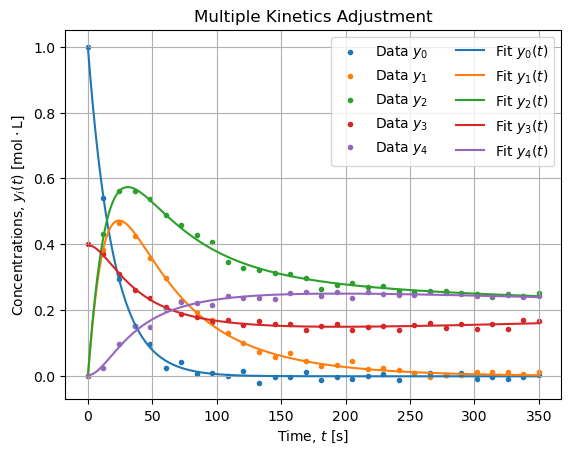

In [15]:
fig, axe = plt.subplots()
for yi in data:
    axe.scatter(t, yi, marker=".")
axe.plot(tlin, fit.y.T)
axe.set_title("Multiple Kinetics Adjustment")
axe.set_xlabel(r"Time, $t$ $[\mathrm{s}]$")
axe.set_ylabel(r"Concentrations, $y_i(t)$ $[\mathrm{mol\cdot L}]$")
axe.legend([f"Data $y_{{{i}}}$" for i in range(5)] + [f"Fit $y_{{{i}}}(t)$" for i in range(5)], ncol=2)
axe.grid()